# Algoritmos de optimización - Seminario

**Grupo:** 21

**Nombre y Apellidos:** Javier Eduardo Ibarra Gutierrez · Juan Manuel Martin Fleitas

**Url:** <https://github.com/jeibarrag/03MIAR-Algoritmos-de-Optimizacion/tree/main/SEMINARIO>

**Problema:** 3. Combinar cifras y operaciones

---

## Descripción del problema

Disponemos de las 9 cifras del 1 al 9 (se excluye el cero) y de los 4 signos de las operaciones
fundamentales: suma (`+`), resta (`-`), multiplicación (`*`) y división (`/`).

Debemos combinarlos alternativamente sin repetir ninguno de ellos para obtener una cantidad dada. Un
ejemplo sería para obtener el 4:

$$4+2-6/3*1 = 4$$

Debe analizarse el problema para encontrar todos los valores enteros posibles planteando las
siguientes cuestiones:

- ¿Qué valor máximo y mínimo se pueden obtener según las condiciones del problema?
- ¿Es posible encontrar todos los valores enteros posibles entre dicho mínimo y máximo?

### Interpretación del problema

Nuestra interpretación del problema es la siguiente. Se dispone de nueve cifras $\{1,2,3,4,5,6,7,8,9\}$
y de los cuatro operadores aritméticos básicos $\{+,-,\times,/\}$. Se pide formar expresiones alternando
cifras y operadores, combinándolos sin repetir ninguno de ellos, para obtener un determinado valor. De
acuerdo con el ejemplo proporcionado (para obtener el 4: `4+2-6/3*1 = 4`), entendemos que:

- Se utilizan solo 5 cifras distintas de entre las 9 disponibles.
- Las cifras utilizadas son distintas, no se repiten cifras.
- Se utilizan los 4 operadores básicos.
- Cada uno de los operadores se utiliza solo una vez.
- Las cifras y los operadores aparecen alternados.
- La precedencia de las operaciones es la habitual y no se utilizan paréntesis.

Una expresión válida tendrá la estructura:

$$d_1 \; op_1 \; d_2 \; op_2 \; d_3 \; op_3 \; d_4 \; op_4 \; d_5$$

siendo:

- $d_i$: cifras distintas elegidas de $\{1,\dots,9\}$.
- $op_i$: los operadores $+,-,\times,/$, utilizados exactamente una vez cada uno.

Las restricciones que debe cumplir cualquier expresión son:

1. **No repetir cifras.** Cada cifra puede utilizarse como máximo una vez.
2. **No repetir operadores.** Cada operador debe utilizarse exactamente una vez.
3. **Alternancia.** Las cifras y operadores deben aparecer alternados.
4. **Precedencia de operaciones.** Se sigue la precedencia habitual de las reglas aritméticas: primero
   multiplicación y división, y luego suma y resta.

El ejemplo del enunciado confirma este último punto. En `4+2-6/3*1` la división y la multiplicación se
resuelven antes que la suma y la resta, con lo que queda $4+2-(6/3)\cdot 1 = 4$. Si se leyera de
izquierda a derecha saldría $((4+2-6)/3)\cdot 1 = 0$, que no es el resultado que da el enunciado.

De esta interpretación se siguen dos consecuencias que vamos a usar más adelante:

- Como el cero está excluido, ninguna expresión divide por cero. Todas las combinaciones que cumplen
  las restricciones son evaluables, así que no hay que descartar ninguna por inválida.
- Como cada operador aparece una sola vez, en cada expresión hay un único `+` y un único `-`. Eso hace
  que toda expresión sea la suma algebraica de exactamente tres términos multiplicativos. Esta
  propiedad es la base de las cotas de poda de la pregunta 8.

In [1]:
# ============================================================
# DATOS GENERALES DEL PROBLEMA
# ============================================================

from itertools import permutations
from fractions import Fraction
from math import factorial
import random
import time

# Cifras disponibles: del 1 al 9 (excluido el cero).
digitos = tuple(range(1, 10))

# Operadores disponibles. Cada expresión válida usa estos cuatro una sola vez.
operadores = ('+', '-', '*', '/')

# Cada expresión usa 5 cifras y 4 operadores.
N_CIFRAS = 5
N_OPS = 4

# Fijamos la semilla para que todo el notebook sea reproducible.
random.seed(2026)


def construir_expresion(cifras, ops):
    """
    Transforma las cifras y operadores en una cadena legible.
    Por ejemplo: cifras = (4, 2, 6, 3, 1) y ops = ('+', '-', '/', '*')
    devuelve "4+2-6/3*1".
    """
    expresion = ""

    # Añadimos cifra y operador de forma alterna.
    for i in range(len(ops)):
        expresion += str(cifras[i]) + ops[i]

    # Al final añadimos la última cifra.
    expresion += str(cifras[len(ops)])

    return expresion


# Comprobamos el ejemplo del enunciado.
ejemplo = construir_expresion((4, 2, 6, 3, 1), ('+', '-', '/', '*'))
print("Ejemplo del enunciado:", ejemplo, "=", eval(ejemplo))
print("La precedencia habitual da el resultado esperado:", eval(ejemplo) == 4)

Ejemplo del enunciado: 4+2-6/3*1 = 4.0
La precedencia habitual da el resultado esperado: True


---
## (*) ¿Cuántas posibilidades hay sin tener en cuenta las restricciones?

## ¿Cuántas posibilidades hay teniendo en cuenta todas las restricciones?

### Respuesta

**Sin tener en cuenta las restricciones.** Entendemos que seguimos manteniendo la estructura general de
la expresión (cifra, operador, cifra, operador, cifra, operador, cifra, operador, cifra), pero
permitimos repetir cifras y permitimos repetir operadores.

En ese caso siguen habiendo 5 posiciones de cifra, y cada una puede tomar cualquiera de las 9 cifras
disponibles porque se permite la repetición. El número de posibilidades viene dado por variaciones con
repetición:

$$VR(9,5) = 9^5 = 59\,049$$

Para los operadores tenemos 4 posiciones y cada una puede tomar cualquiera de los 4 operadores, así que
también son variaciones con repetición:

$$VR(4,4) = 4^4 = 256$$

El número total de expresiones queda entonces:

$$9^5 \times 4^4 = 59\,049 \times 256 = 15\,116\,544$$

**Teniendo en cuenta todas las restricciones.** Por un lado debemos elegir 5 cifras distintas de entre
las 9 disponibles y además colocarlas en orden. El número de formas posibles es una variación sin
repetición, $V(n,k) = \dfrac{n!}{(n-k)!}$ con $n=9$ y $k=5$:

$$V(9,5) = \frac{9!}{(9-5)!} = 15\,120$$

Por otro lado, los cuatro operadores deben aparecer exactamente una vez. La forma de combinarlos es
otra variación sin repetición, ahora con $n=4$ y $k=4$:

$$V(4,4) = \frac{4!}{(4-4)!} = \frac{4!}{0!} = 4! = 24$$

Por cada ordenación posible de las cifras existen 24 formas de colocar los operadores, así que:

$$15\,120 \times 24 = 362\,880$$

Existen por tanto 362.880 expresiones válidas. Un detalle que llama la atención es que ese número es
exactamente $9!$. La razón es que el $4!$ del denominador de $V(9,5)$ se cancela con el $4!$ de las
permutaciones de operadores.

Comparando ambos casos, las restricciones reducen el espacio de posibilidades en:

$$\frac{\text{sin restricciones}}{\text{con restricciones}} = \frac{15\,116\,544}{362\,880} \approx 41{,}66$$

El problema con restricciones tiene aproximadamente 42 veces menos posibilidades que el problema sin
ellas.

Hay que señalar además que las 362.880 expresiones son **todas evaluables**. Al no estar el cero entre
las cifras, ninguna de ellas divide por cero, así que el espacio de búsqueda coincide con el espacio de
soluciones factibles y no hace falta descartar candidatos por ser inválidos.

**Nota sobre la notación.** Usamos $VR$ para las variaciones **con** repetición y $V$ para las
variaciones **sin** repetición. Son cosas distintas y conviene no mezclarlas: $VR(9,5) = 9^5 = 59\,049$,
mientras que $V(9,5) = 9!/4! = 15\,120$. En el caso con restricciones la que interviene es siempre $V$.

In [2]:
# ============================================================
# CARDINALIDAD DEL ESPACIO DE SOLUCIONES
# ============================================================

# --- Sin restricciones: variaciones CON repetición ---------------------------
# 5 posiciones de cifra con 9 opciones cada una, y 4 posiciones de operador
# con 4 opciones cada una.
vr_cifras = len(digitos) ** N_CIFRAS          # VR(9,5) = 9^5
vr_ops = len(operadores) ** N_OPS             # VR(4,4) = 4^4
sin_restricciones = vr_cifras * vr_ops

# --- Con restricciones: variaciones SIN repetición ---------------------------
# V(9,5) formas de elegir y ordenar 5 cifras distintas.
v_cifras = factorial(9) // factorial(9 - N_CIFRAS)
# V(4,4) = 4! formas de ordenar los cuatro operadores.
v_ops = factorial(N_OPS)
con_restricciones = v_cifras * v_ops

print("SIN restricciones (se permite repetir)")
print(f"  VR(9,5) = 9^5 = {vr_cifras:,}")
print(f"  VR(4,4) = 4^4 = {vr_ops:,}")
print(f"  total   = {vr_cifras:,} x {vr_ops:,} = {sin_restricciones:,}")

print("\nCON restricciones (sin repetir)")
print(f"  V(9,5)  = 9!/4! = {v_cifras:,}")
print(f"  V(4,4)  = 4!    = {v_ops:,}")
print(f"  total   = {v_cifras:,} x {v_ops} = {con_restricciones:,}")
print(f"  comprobación: 362.880 = 9! -> {con_restricciones == factorial(9)}")

print(f"\nLas restricciones reducen el espacio en un factor de "
      f"{sin_restricciones / con_restricciones:.2f}")

# Comprobamos que itertools genera exactamente ese número de expresiones.
generadas = (sum(1 for _ in permutations(digitos, N_CIFRAS))
             * sum(1 for _ in permutations(operadores)))
print(f"Expresiones generadas realmente por itertools: {generadas:,} "
      f"-> {generadas == con_restricciones}")

SIN restricciones (se permite repetir)
  VR(9,5) = 9^5 = 59,049
  VR(4,4) = 4^4 = 256
  total   = 59,049 x 256 = 15,116,544

CON restricciones (sin repetir)
  V(9,5)  = 9!/4! = 15,120
  V(4,4)  = 4!    = 24
  total   = 15,120 x 24 = 362,880
  comprobación: 362.880 = 9! -> True

Las restricciones reducen el espacio en un factor de 41.66
Expresiones generadas realmente por itertools: 362,880 -> True


---
## Modelo para el espacio de soluciones

## (*) ¿Cuál es la estructura de datos que mejor se adapta al problema? Argumentalo. (Es posible que hayas elegido una al principio y veas la necesidad de cambiar, argumentalo)

### Respuesta

Inicialmente escogimos **tuplas** para representar las expresiones, ya que mantienen el orden de cifras
y operadores y son inmutables, con lo que `itertools.permutations` las produce directamente sin coste
añadido. Para almacenar los resultados usamos un **conjunto** (`set`), porque evita duplicados y
permite búsquedas eficientes. Podríamos haber usado una lista, pero nos decantamos por el conjunto
por el elevado número de repeticiones: de las 362.880 expresiones salen solo 147 valores enteros
distintos, así que la mayoría de resultados se repiten muchas veces.

Al avanzar con el trabajo vimos que había que cambiar dos cosas.

**Del conjunto al diccionario.** El conjunto responde si un valor es alcanzable, pero no dice *con qué
expresión*. En cuanto quisimos mostrar la expresión que produce cada resultado tuvimos que pasar a un
**diccionario** `{valor_entero: expresión}`. Sigue siendo una tabla hash, así que la búsqueda continúa
siendo $O(1)$, pero además guarda un testigo de cada valor. Este cambio es el que después permite
resolver cualquier consulta sin repetir el barrido, y es la base de la tercera mejora de la pregunta 8.

**De `Fraction` al par de enteros.** Para evaluar las expresiones usamos al principio
`fractions.Fraction`, que hace aritmética exacta y evita los errores de precisión de los `float` en las
divisiones. Funciona bien y es la que mantenemos en el algoritmo por fuerza bruta, pero al medirla
vimos que es lenta: normaliza con el máximo común divisor en cada operación, y eso se nota cuando se
repite cientos de miles de veces. Como alternativa representamos el valor de una expresión con un
**par de enteros** `(numerador, denominador)` sin reducir. Es igual de exacto y mucho más rápido, como
se ve en la medición de abajo, y comprobar si el resultado es entero se reduce a
`numerador % denominador == 0`.

Sobre esto último hicimos una comprobación que merece la pena mencionar. Como en cada expresión hay una
sola división y su divisor es una única cifra, el denominador de cualquier expresión divide siempre a 9.
Eso significa que un valor no entero está como mínimo a $1/9 \approx 0{,}111$ del entero más próximo, y
que la distancia nunca se acerca al error del `float`. Lo verificamos sobre las 362.880 expresiones y no
hay ni un solo caso en que el criterio con `float` y el criterio exacto discrepen. Es decir, en este
problema concreto el `float` habría bastado, pero para saberlo hemos tenido que demostrarlo, y esa
garantía deja de valer en cuanto se permite más de una división. Por eso trabajamos con aritmética
exacta.

En resumen, la combinación que usamos es:

| Estructura | Para qué |
|---|---|
| tupla de cifras y tupla de operadores | representar una expresión |
| par de enteros `(num, den)` | valor exacto de una expresión, sin errores de precisión |
| diccionario `{valor: expresión}` | guardar los resultados y consultarlos en $O(1)$ |

In [3]:
# ============================================================
# EVALUACIÓN DE UNA EXPRESIÓN
# ============================================================
# Damos dos versiones. La primera con Fraction, que es la que usamos en el
# algoritmo por fuerza bruta. La segunda con un par de enteros, más rápida,
# que es la que usa el algoritmo mejorado de la pregunta 8.


def evaluar_expresion(cifras, ops):
    """
    Evalúa una expresión formada por 5 cifras y 4 operadores respetando la
    prioridad habitual de las operaciones.

    Se usa Fraction para evitar errores de precisión en las divisiones.

    La idea es que un término se cierra cuando aparece una suma o una resta.
    Mientras aparezcan multiplicaciones o divisiones el término sigue abierto.
    """

    # Lista donde iremos guardando los términos ya cerrados.
    terminos = []

    # Signos asociados a cada término. El primero siempre es positivo.
    signos = [1]

    # El término actual empieza siendo la primera cifra.
    termino_actual = Fraction(cifras[0])

    # Recorremos a la vez los operadores y las cifras restantes.
    for operador, cifra in zip(ops, cifras[1:]):

        cifra = Fraction(cifra)

        # Multiplicación y división no cierran el término, lo actualizan.
        if operador == '*':
            termino_actual = termino_actual * cifra
        elif operador == '/':
            termino_actual = termino_actual / cifra

        # Suma y resta cierran el término actual y abren uno nuevo.
        elif operador == '+':
            terminos.append(termino_actual)
            signos.append(1)
            termino_actual = cifra
        elif operador == '-':
            terminos.append(termino_actual)
            signos.append(-1)
            termino_actual = cifra

    # Al salir del bucle queda el último término pendiente de guardar.
    terminos.append(termino_actual)

    # Sumamos todos los términos con su signo.
    return sum(signo * termino for signo, termino in zip(signos, terminos))


def evaluar_par(cifras, ops):
    """
    Misma evaluación que la anterior, pero devolviendo el par (num, den) sin
    normalizar en lugar de un Fraction. Es exacta igualmente y bastante más
    rápida, porque se ahorra el cálculo del máximo común divisor.
    """

    acum_num, acum_den = 0, 1        # términos ya cerrados
    signo = 1                        # signo del término en curso
    term_num, term_den = cifras[0], 1  # término en curso

    for i, operador in enumerate(ops):
        cifra = cifras[i + 1]

        if operador == '*':
            term_num *= cifra
        elif operador == '/':
            term_den *= cifra
        else:
            # Cerramos el término en curso y lo acumulamos.
            acum_num = acum_num * term_den + signo * term_num * acum_den
            acum_den = acum_den * term_den
            signo = 1 if operador == '+' else -1
            term_num, term_den = cifra, 1

    # Cerramos el último término.
    return (acum_num * term_den + signo * term_num * acum_den, acum_den * term_den)


# --- Comprobamos que las dos versiones coinciden entre sí y con eval ---------
casos = [((4, 2, 6, 3, 1), ('+', '-', '/', '*')),
         ((1, 2, 3, 7, 4), ('+', '*', '/', '-')),
         ((9, 8, 7, 6, 5), ('/', '-', '*', '+'))]

print(f"{'expresión':<12} {'Fraction':>10} {'par (num,den)':>16} {'eval':>12}   ok")
for c, o in casos:
    v1 = evaluar_expresion(c, o)
    num, den = evaluar_par(c, o)
    v2 = Fraction(num, den)
    v3 = eval(construir_expresion(c, o))
    print(f"{construir_expresion(c, o):<12} {str(v1):>10} {str((num, den)):>16} "
          f"{v3:>12.6f}   {v1 == v2 and abs(float(v1) - v3) < 1e-9}")

# --- Comparamos la velocidad de las dos representaciones --------------------
t0 = time.perf_counter()
for _ in range(200_000):
    Fraction(3, 4) * Fraction(5, 6)
t_fraction = time.perf_counter() - t0

t0 = time.perf_counter()
for _ in range(200_000):
    (3 * 5, 4 * 6)
t_par = time.perf_counter() - t0

print(f"\n200.000 productos: Fraction {t_fraction:.3f} s frente a par de enteros "
      f"{t_par:.3f} s ({t_fraction / t_par:.0f} veces más rápido)")

expresión      Fraction    par (num,den)         eval   ok
4+2-6/3*1             4          (12, 3)     4.000000   True
1+2*3/7-4         -15/7         (-15, 7)    -2.142857   True
9/8-7*6+5        -287/8        (-287, 8)   -35.875000   True



200.000 productos: Fraction 0.631 s frente a par de enteros 0.006 s (100 veces más rápido)


---
## Según el modelo para el espacio de soluciones

## (*) ¿Cuál es la función objetivo?

## (*) ¿Es un problema de maximización o minimización?

### Respuesta

En principio, creemos que el problema original no tiene una función objetivo de optimización. El
problema consiste en encontrar una expresión válida que produzca una cantidad dada, algo que podría
modelarse como

$$f(B) = A$$

donde $B$ es una expresión que cumple las restricciones y $A$ el valor buscado. Visto así se trata de
un problema de búsqueda bajo restricciones, no de optimización: no hay nada que maximizar ni
minimizar, solo una condición que cumplir o no cumplir.

Ahora bien, para poder atacarlo con las técnicas de la asignatura nos interesa reformularlo como un
problema de optimización. La forma natural de hacerlo es tomar como función objetivo la distancia
entre el valor de la expresión y el objetivo buscado:

$$f(E) = \bigl|\,valor(E) - N\,\bigr| \qquad \text{con } E \in S$$

siendo $S$ el conjunto de las 362.880 expresiones válidas. Planteado así es un problema de
**minimización**, y el valor $N$ es alcanzable justo cuando el mínimo vale 0.

Esta reformulación no es solo una cuestión de forma. Al asignar un número a cada expresión, aunque no
sea solución, el espacio pasa a tener una noción de "estar más cerca o más lejos" del objetivo que la
formulación original no tiene. Es lo que después nos permite descartar ramas enteras en la pregunta 8:
si sabemos que desde cierto punto ya no se puede llegar a $N$, no hace falta seguir explorando.

Aparte de eso, las dos preguntas del enunciado sobre el valor máximo y el mínimo sí son problemas de
optimización en sentido estricto, uno de **maximización** y otro de **minimización**:

$$\max_{E \in S} valor(E) \qquad\text{y}\qquad \min_{E \in S} valor(E)$$

Los dos se resuelven de una sola pasada, porque el conjunto de expresiones válidas es el mismo.

Recogiendo las tres componentes del modelo:

- **Variables de decisión:** las cinco cifras $d_1,\dots,d_5$ y los cuatro operadores
  $op_1,\dots,op_4$, junto con la posición que ocupa cada uno.
- **Restricciones:** las cuatro que enumeramos en la interpretación del problema.
- **Función objetivo:** $|valor(E)-N|$ a minimizar, si buscamos un valor concreto; o $valor(E)$ a
  maximizar o minimizar, si lo que buscamos son los extremos del rango.

In [4]:
# ============================================================
# FUNCIÓN OBJETIVO
# ============================================================


def desviacion(cifras, ops, objetivo):
    """
    Función objetivo del problema reformulado: |valor(E) - N|, a minimizar.

    Se devuelve como par (num, den) para no perder exactitud. El objetivo se
    alcanza cuando el numerador es 0.
    """
    num, den = evaluar_par(cifras, ops)
    return abs(num - objetivo * den), den


# Con la expresión del enunciado y objetivo 4 la desviación debe ser 0.
num, den = desviacion((4, 2, 6, 3, 1), ('+', '-', '/', '*'), 4)
print(f"Desviación de 4+2-6/3*1 respecto de N=4: {num}/{den} -> "
      f"objetivo alcanzado: {num == 0}")

# Con objetivo 10 la desviación es 6.
num, den = desviacion((4, 2, 6, 3, 1), ('+', '-', '/', '*'), 10)
print(f"Desviación de 4+2-6/3*1 respecto de N=10: {num}/{den} = {num / den} -> "
      f"objetivo alcanzado: {num == 0}")

Desviación de 4+2-6/3*1 respecto de N=4: 0/3 -> objetivo alcanzado: True
Desviación de 4+2-6/3*1 respecto de N=10: 18/3 = 6.0 -> objetivo alcanzado: False


---
## Diseña un algoritmo para resolver el problema por fuerza bruta

### Respuesta

Hemos diseñado un algoritmo por fuerza bruta que genera todas las expresiones válidas posibles.
Teniendo en cuenta que cada expresión tiene que cumplir las restricciones impuestas, esto es, que está
formada por cinco cifras distintas tomadas de $\{1,\dots,9\}$ y por los cuatro operadores usados una
sola vez, generamos todas las permutaciones de cifras y todas las permutaciones de operadores. Cada
expresión se evalúa respetando la prioridad normal de las operaciones. Si el resultado es entero se
guarda en un diccionario junto con la expresión que lo produce, de forma que al final tenemos un
testigo de cada valor alcanzable.

En pseudocódigo:

```
ALGORITMO fuerza_bruta
  resultados <- diccionario vacío
  PARA cada variación D de 5 cifras distintas tomadas de {1..9}:    # V(9,5) = 15.120
      PARA cada permutación O de los 4 operadores:                  # 4! = 24
          v <- evaluar(D, O)                                        # con Fraction
          SI v es entero Y v no está todavía en resultados:
              resultados[v] <- construir_expresion(D, O)
  DEVOLVER resultados
```

Al terminar obtenemos el valor mínimo, el valor máximo y podemos comprobar si están presentes todos
los enteros comprendidos entre ambos. El algoritmo evalúa $V(9,5) \cdot 4! = 362\,880$ expresiones, un
tamaño relativamente pequeño que hace viable este tipo de algoritmo.

Que la fuerza bruta sea viable aquí es importante por una razón que va más allá de resolver el
problema: nos da la respuesta exacta contra la que comparar cualquier otro algoritmo. Todo lo que
hagamos en las preguntas 8 y 9 lo validaremos exigiendo que devuelva exactamente el mismo conjunto de
147 valores.

In [5]:
# ============================================================
# ALGORITMO 1 - FUERZA BRUTA
# ============================================================


def fuerza_bruta(cifras_disp=digitos, ops_disp=operadores, k=N_CIFRAS):
    """
    Recorre todas las expresiones válidas y devuelve:
      - un diccionario {valor_entero: expresión} con un testigo de cada valor
      - el número de expresiones evaluadas
    """

    resultados = {}
    contador = 0

    # Todas las formas de elegir y ordenar k cifras distintas.
    for cifras in permutations(cifras_disp, k):

        # Todas las formas de ordenar los operadores.
        for ops in permutations(ops_disp):

            contador += 1
            valor = evaluar_expresion(cifras, ops)

            # Como valor es un Fraction, es entero si su denominador es 1.
            if valor.denominator == 1:
                entero = int(valor)
                if entero not in resultados:
                    resultados[entero] = construir_expresion(cifras, ops)

    return resultados, contador


def fuerza_bruta_objetivo(objetivo, cifras_disp=digitos, ops_disp=operadores, k=N_CIFRAS):
    """
    Variante que busca la primera expresión cuyo valor sea el objetivo y para
    en cuanto la encuentra. Devuelve (expresión, expresiones evaluadas).

    Usamos aquí evaluar_par en vez de evaluar_expresion a propósito. Esta
    función es la que vamos a comparar contra la búsqueda con poda de la
    pregunta 8, y si una usara Fraction y la otra no, estaríamos midiendo a la
    vez el efecto de la poda y el del cambio de representación. Con el mismo
    evaluador en las dos, la diferencia que salga es solo mérito de la poda.
    """

    contador = 0
    for cifras in permutations(cifras_disp, k):
        for ops in permutations(ops_disp):
            contador += 1
            num, den = evaluar_par(cifras, ops)
            if num == objetivo * den:
                return construir_expresion(cifras, ops), contador
    return None, contador


# --- Ejecutamos el barrido completo -----------------------------------------
t0 = time.perf_counter()
RESULTADOS_FB, N_EXPRESIONES = fuerza_bruta()
T_FUERZA_BRUTA = time.perf_counter() - t0

minimo, maximo = min(RESULTADOS_FB), max(RESULTADOS_FB)

print(f"Expresiones evaluadas:      {N_EXPRESIONES:,}")
print(f"Valores enteros distintos:  {len(RESULTADOS_FB)}")
print(f"Tiempo:                     {T_FUERZA_BRUTA:.2f} s")
print(f"\nValor mínimo: {minimo:>4}  ->  {RESULTADOS_FB[minimo]}")
print(f"Valor máximo: {maximo:>4}  ->  {RESULTADOS_FB[maximo]}")

# ¿Falta algún entero entre el mínimo y el máximo?
faltan = [n for n in range(minimo, maximo + 1) if n not in RESULTADOS_FB]
if not faltan:
    print(f"\nSe obtienen todos los enteros entre {minimo} y {maximo}.")
else:
    print(f"\nFaltan estos enteros: {faltan}")

Expresiones evaluadas:      362,880
Valores enteros distintos:  147
Tiempo:                     6.81 s

Valor mínimo:  -69  ->  1+4/2-8*9
Valor máximo:   77  ->  7/1-2+8*9

Se obtienen todos los enteros entre -69 y 77.


---
## Calcula la complejidad del algoritmo por fuerza bruta

### Respuesta

En la respuesta a la pregunta 2 vimos que hay $V(9,5) = 15\,120$ formas de elegir y ordenar cinco
cifras distintas y $4! = 24$ formas de ordenar los operadores, lo que da $15\,120 \cdot 24 = 362\,880$
expresiones evaluadas.

Ese número es la cuenta de este caso concreto, pero para hablar de complejidad hay que expresarla en
función del tamaño de la entrada. Llamamos $n$ al número de cifras disponibles y $k$ al número de
operadores, de manera que la expresión tiene $k+1$ cifras. El algoritmo tiene entonces dos bucles
anidados y un cuerpo:

| Elemento | Repeticiones | Coste |
|---|---|---|
| Bucle externo, variaciones de cifras | $V_{n,k+1} = \dfrac{n!}{(n-k-1)!}$ | — |
| Bucle interno, permutaciones de operadores | $k!$ | — |
| Evaluar la expresión | — | $\Theta(k)$ |
| Construir la cadena | — | $\Theta(k)$ |

Evaluar una expresión no cuesta un número constante de operaciones: hay que recorrer los $k$ operadores
uno a uno, así que cuesta $\Theta(k)$. Multiplicando:

$$T(n,k) = \Theta\!\left( \frac{n!}{(n-k-1)!} \cdot k! \cdot k \right)$$

Con $n=9$ y $k=4$ salen $15\,120 \cdot 24 \cdot 4 = 1\,451\,520$ operaciones elementales.

**Orden de complejidad.** Si $k$ crece junto con $n$, que es el caso interesante porque la expresión se
alarga al haber más operadores disponibles, el término $n!/(n-k-1)!$ tiende a $n!$ y la complejidad es
$O(n!\,k!\,k)$, es decir **factorial**, el peor orden de la tabla de la asignatura. Si en cambio $k$
queda fijo y solo crece $n$, se reduce a $O(n^{k+1})$, polinómica de grado $k+1$.

Es importante no dejar la respuesta en $O(362\,880)$. La notación $O$ grande de una constante es
$O(1)$, así que escribirlo de esa manera no informaría de nada: la gracia del análisis está justamente
en saber cómo crece el coste cuando crece el problema, y para eso hay que dejarlo en función de $n$ y
de $k$.

**Complejidad espacial.** Guardamos una entrada por cada valor entero distinto, o sea $O(|R|)$ siendo
$R$ el conjunto de valores alcanzables, que en nuestro caso son 147 entradas. Es despreciable al lado
del coste en tiempo.

**Casos mejor, peor y promedio.** El barrido completo siempre recorre las 362.880 expresiones, así que
no distingue casos. La variante que busca un objetivo concreto sí: en el mejor caso lo encuentra a la
primera, $\Omega(1)$; en el peor el objetivo no es alcanzable y agota el espacio,
$\Theta(n!\,k!\,k)$; y en promedio depende de cuántas expresiones produzcan ese valor concreto, lo que
da diferencias enormes entre unos objetivos y otros, como se ve en la pregunta 11.

In [6]:
# ============================================================
# COMPROBACIÓN EMPÍRICA DE LA COMPLEJIDAD DE LA FUERZA BRUTA
# ============================================================
# Hacemos crecer n (cifras disponibles) manteniendo k = 4 y comprobamos que
# el número de expresiones sigue la fórmula V(n,5)*4! y que el tiempo crece
# en la misma proporción.

ESCALA = {}          # lo reutilizamos en la pregunta 9

print(f"{'n':>3} {'V(n,5)*4!':>12} {'evaluadas':>12} {'tiempo (s)':>12} {'ratio':>8}")
t_anterior = None
for n in range(5, 10):
    subconjunto = tuple(range(1, n + 1))
    teorico = factorial(n) // factorial(n - N_CIFRAS) * factorial(N_OPS)

    if n == 9:
        # Para n=9 ya tenemos el barrido hecho más arriba, no lo repetimos.
        t, evaluadas = T_FUERZA_BRUTA, N_EXPRESIONES
    else:
        t0 = time.perf_counter()
        _, evaluadas = fuerza_bruta(cifras_disp=subconjunto)
        t = time.perf_counter() - t0

    ESCALA[n] = t
    ratio = f"{t / t_anterior:.2f}x" if t_anterior else "-"
    t_anterior = t
    print(f"{n:>3} {teorico:>20,} {evaluadas:>12,} {t:>12.2f} {ratio:>8}")

print("\nEl número real de expresiones coincide con la fórmula en todos los casos.")

  n    V(n,5)*4!    evaluadas   tiempo (s)    ratio
  5                2,880        2,880         0.05        -


  6               17,280       17,280         0.32    6.25x


  7               60,480       60,480         1.11    3.48x


  8              161,280      161,280         3.10    2.80x
  9              362,880      362,880         6.81    2.20x

El número real de expresiones coincide con la fórmula en todos los casos.


---
## (*) Diseña un algoritmo que mejore la complejidad del algoritmo por fuerza bruta. Argumenta porque crees que mejora el algoritmo por fuerza bruta

### Respuesta

Antes de proponer nada conviene distinguir qué se puede mejorar y qué no, porque no todas las preguntas
del enunciado admiten la misma ganancia.

Si lo que queremos es el barrido completo, es decir, saber *todos* los valores alcanzables, no se puede
bajar del tamaño del espacio. Cualquier algoritmo exacto que garantice que no se ha dejado ningún valor
fuera tiene que considerar, de una forma u otra, las 362.880 expresiones. Lo que sí podemos mejorar es
el coste de cada expresión y el número de ramas que llegamos a explorar. Planteamos tres mejoras, cada
una atacando un frente distinto.

---

#### Mejora 1. Recorrido incremental en árbol

La fuerza bruta trata cada expresión como algo aislado y la evalúa desde cero. Pero las expresiones que
empiezan igual comparten el cálculo del principio. Por ejemplo, fijado el prefijo `1+2` quedan tres
cifras por elegir de entre las siete restantes y tres operadores por colocar, lo que da
$V_{7,3}\cdot 3! = 210 \cdot 6 = 1\,260$ expresiones distintas. Las 1.260 vuelven a calcular ese mismo
`1+2` desde el principio.

La mejora consiste en organizar la búsqueda como el recorrido en profundidad de un árbol, donde cada
nivel fija una cifra y un operador y se va arrastrando el valor parcial acumulado. Así cada nodo hace
un trabajo constante en lugar de $\Theta(k)$, y el cálculo del prefijo se aprovecha en todo el subárbol
que cuelga de él.

El número de nodos del árbol es

$$\mathcal{N}(n,k) = \sum_{i=0}^{k} V_{n,\,i+1} \cdot V_{k,\,i}$$

que con $n=9$ y $k=4$ da $9 + 288 + 6\,048 + 72\,576 + 362\,880 = 441\,801$ nodos de coste constante,
frente a las 1.451.520 operaciones de la fuerza bruta. Sobre el papel la ganancia es de unas 3,3 veces,
y en la práctica sale bastante mayor porque además nos ahorramos el trabajo de `Fraction`.

#### Mejora 2. Vuelta atrás con poda por cotas

Cuando lo que buscamos es una expresión que valga exactamente $N$, el árbol se puede podar. Aquí es
donde usamos la propiedad que señalamos en la interpretación del problema: como cada operador aparece
una sola vez, hay un único `+` y un único `-`, y por tanto toda expresión es la suma algebraica de
**tres términos multiplicativos**. Además cada término tiene como mucho tres cifras y como mucho un `*`
y un `/`, de donde se deduce que cualquier término está acotado:

$$\tfrac{1}{9} \le T \le 72$$

El máximo, 72, sale de un término de dos cifras con multiplicación ($9 \cdot 8$, porque las cifras son
distintas). El mínimo, $1/9$, de uno de dos cifras con división.

Con esa cota, en cada nodo calculamos entre qué valores se puede mover todavía el resultado final:
sumamos al acumulado el rango en que puede quedar el término que estamos construyendo, más el rango de
los términos que faltan según qué operadores aditivos queden por colocar. Si $N$ se sale de ese
intervalo, la rama entera se descarta sin explorarla.

La poda no cambia el orden de complejidad en el peor caso, porque si las cotas no ajustan hay que
recorrerlo todo igual. Lo que hace es reducir mucho el número de nodos visitados en el caso medio, que
es exactamente lo que se espera de la técnica de vuelta atrás: el orden sigue siendo el mismo salvo que
la poda evite explorar buena parte del árbol.

Para medir esta mejora comparamos contra una fuerza bruta que usa el mismo evaluador exacto que la
versión podada. Si dejáramos la fuerza bruta con `Fraction` estaríamos midiendo dos cosas a la vez, el
efecto de la poda y el del cambio de representación, y la comparación no diría nada limpio sobre la
poda. Con el evaluador igualado, la diferencia que sale es solo mérito de las cotas.

#### Mejora 3. Tabular una vez y consultar después

Esta sí mejora el orden de complejidad, y es la más útil en la práctica. Responder a $Q$ preguntas del
tipo "¿es alcanzable $N_i$?" cuesta, con fuerza bruta, $Q$ barridos independientes:

$$O\bigl(Q \cdot V_{n,k+1} \cdot k! \cdot k\bigr)$$

Si en cambio hacemos **un solo barrido** que guarde todos los valores alcanzables en un diccionario,
cada consulta posterior se resuelve con un acceso a tabla hash en $O(1)$:

$$O\bigl(V_{n,k+1} \cdot k!\bigr) + O(Q)$$

Para $Q$ grande la diferencia es de varios órdenes de magnitud, y el precálculo se amortiza ya en la
segunda consulta. Es la idea de la memoización de la programación dinámica: se paga el cálculo una vez
y se reutiliza siempre. Nuestro segundo script ya apuntaba a esto sin llamarlo así, al guardar las
soluciones en un diccionario antes de recorrer el juego de datos.

---

**Resumen del argumento.** La primera mejora reduce el trabajo por nodo, la segunda reduce el número de
nodos que llegamos a visitar, y la tercera reduce el orden de complejidad respecto al número de
consultas. Solo la tercera cambia la $O$ grande, y preferimos decirlo así antes que atribuir a la poda
una mejora asintótica que no tiene.

In [7]:
# ============================================================
# ALGORITMO 2 - MEJORA 1: recorrido incremental en árbol
# ============================================================


def recorrido_incremental(cifras_disp=digitos, ops_disp=operadores):
    """
    Barrido completo mediante recorrido en profundidad, arrastrando el valor
    parcial en lugar de recalcularlo en cada expresión.

    Devuelve (diccionario de resultados, número de nodos visitados).

    El estado que se va pasando en la recursión es:
      acum_num/acum_den -> valor de los términos ya cerrados
      signo             -> signo con el que entra el término en curso
      term_num/term_den -> término multiplicativo en curso
    """

    resultados = {}
    nodos = [0]

    def explorar(libres, ops_restantes, acum_num, acum_den,
                 signo, term_num, term_den, expresion):

        nodos[0] += 1

        # Si ya no quedan operadores, la expresión está completa.
        if not ops_restantes:
            num = acum_num * term_den + signo * term_num * acum_den
            den = acum_den * term_den

            # Comprobación exacta de si el resultado es entero.
            if num % den == 0:
                valor = num // den
                if valor not in resultados:
                    resultados[valor] = expresion
            return

        # Elegimos el siguiente operador y la siguiente cifra.
        for i, operador in enumerate(ops_restantes):
            resto_ops = ops_restantes[:i] + ops_restantes[i + 1:]

            for j, cifra in enumerate(libres):
                resto_cifras = libres[:j] + libres[j + 1:]
                nueva = expresion + operador + str(cifra)

                if operador == '*':
                    explorar(resto_cifras, resto_ops, acum_num, acum_den,
                             signo, term_num * cifra, term_den, nueva)
                elif operador == '/':
                    explorar(resto_cifras, resto_ops, acum_num, acum_den,
                             signo, term_num, term_den * cifra, nueva)
                else:
                    # Cerramos el término en curso y abrimos uno nuevo.
                    nuevo_num = acum_num * term_den + signo * term_num * acum_den
                    nuevo_den = acum_den * term_den
                    explorar(resto_cifras, resto_ops, nuevo_num, nuevo_den,
                             1 if operador == '+' else -1, cifra, 1, nueva)

    # Arrancamos eligiendo la primera cifra.
    for j, cifra in enumerate(cifras_disp):
        explorar(cifras_disp[:j] + cifras_disp[j + 1:], ops_disp,
                 0, 1, 1, cifra, 1, str(cifra))

    return resultados, nodos[0]


# --- Comparamos con la fuerza bruta -----------------------------------------
t0 = time.perf_counter()
RESULTADOS_INC, N_NODOS = recorrido_incremental()
T_INCREMENTAL = time.perf_counter() - t0

print(f"{'':<24}{'fuerza bruta':>16}{'incremental':>16}")
print(f"{'expresiones / nodos':<24}{N_EXPRESIONES:>16,}{N_NODOS:>16,}")
print(f"{'valores enteros':<24}{len(RESULTADOS_FB):>16}{len(RESULTADOS_INC):>16}")
print(f"{'tiempo (s)':<24}{T_FUERZA_BRUTA:>16.2f}{T_INCREMENTAL:>16.2f}")
print(f"{'mejora':<24}{'-':>16}{f'{T_FUERZA_BRUTA / T_INCREMENTAL:.1f}x':>16}")

# Los dos algoritmos tienen que dar exactamente lo mismo.
assert set(RESULTADOS_FB) == set(RESULTADOS_INC)
print(f"\nLos dos algoritmos encuentran el mismo conjunto de "
      f"{len(RESULTADOS_INC)} valores.")

# Comprobamos el número de nodos contra la fórmula.
nodos_teoricos = sum(
    (factorial(9) // factorial(9 - (i + 1))) * (factorial(4) // factorial(4 - i))
    for i in range(N_OPS + 1)
)
print(f"Nodos según la fórmula: {nodos_teoricos:,}")
print(f"Nodos contados:         {N_NODOS:,}  ->  coinciden: {nodos_teoricos == N_NODOS}")

                            fuerza bruta     incremental
expresiones / nodos              362,880         441,801
valores enteros                      147             147
tiempo (s)                          6.81            0.37
mejora                                 -           18.4x

Los dos algoritmos encuentran el mismo conjunto de 147 valores.
Nodos según la fórmula: 441,801
Nodos contados:         441,801  ->  coinciden: True


In [8]:
# ============================================================
# ALGORITMO 3 - MEJORA 2: vuelta atrás con poda por cotas
# ============================================================
# Como hay un solo '+' y un solo '-', la expresión son tres términos
# multiplicativos. Cada término tiene como mucho un '*' y un '/', así que
# su valor está siempre entre 1/9 y 72.

TERMINO_MAX = 72.0
TERMINO_MIN = 1.0 / 9.0
MARGEN = 1e-9      # margen de seguridad al comparar las cotas en float


def busqueda_con_poda(objetivo, cifras_disp=digitos, ops_disp=operadores):
    """
    Busca una expresión que valga exactamente el objetivo, descartando las
    ramas desde las que ya no se puede llegar a él.

    Devuelve (expresión o None, número de nodos visitados).

    La comparación final es exacta, con aritmética entera. Las cotas se
    calculan en float solo para decidir la poda, con un margen que garantiza
    que nunca se descarta una rama que sí llevaba a solución.
    """

    encontrada = [None]
    nodos = [0]

    def explorar(libres, ops_restantes, acum_num, acum_den,
                 signo, term_num, term_den, expresion):

        if encontrada[0] is not None:
            return
        nodos[0] += 1

        if not ops_restantes:
            num = acum_num * term_den + signo * term_num * acum_den
            den = acum_den * term_den
            if num == objetivo * den:
                encontrada[0] = expresion
            return

        # --- PODA: entre qué valores puede quedar todavía el resultado ------
        acumulado = acum_num / acum_den
        termino = term_num / term_den

        # Términos que quedan por abrir, y con qué signo entrarán.
        futuros_mas = ops_restantes.count('+')
        futuros_menos = ops_restantes.count('-')

        # El término en curso aún puede crecer si queda '*', o menguar si queda '/'.
        term_alto = termino * 9 if '*' in ops_restantes else termino
        term_bajo = termino / 9 if '/' in ops_restantes else termino

        alto = (acumulado + (term_alto if signo > 0 else -term_bajo)
                + futuros_mas * TERMINO_MAX - futuros_menos * TERMINO_MIN)
        bajo = (acumulado + (term_bajo if signo > 0 else -term_alto)
                + futuros_mas * TERMINO_MIN - futuros_menos * TERMINO_MAX)

        if objetivo < bajo - MARGEN or objetivo > alto + MARGEN:
            return          # descartamos la rama entera

        # --- Ramificación ---------------------------------------------------
        for i, operador in enumerate(ops_restantes):
            resto_ops = ops_restantes[:i] + ops_restantes[i + 1:]

            for j, cifra in enumerate(libres):
                resto_cifras = libres[:j] + libres[j + 1:]
                nueva = expresion + operador + str(cifra)

                if operador == '*':
                    explorar(resto_cifras, resto_ops, acum_num, acum_den,
                             signo, term_num * cifra, term_den, nueva)
                elif operador == '/':
                    explorar(resto_cifras, resto_ops, acum_num, acum_den,
                             signo, term_num, term_den * cifra, nueva)
                else:
                    nuevo_num = acum_num * term_den + signo * term_num * acum_den
                    nuevo_den = acum_den * term_den
                    explorar(resto_cifras, resto_ops, nuevo_num, nuevo_den,
                             1 if operador == '+' else -1, cifra, 1, nueva)

                if encontrada[0] is not None:
                    return

    for j, cifra in enumerate(cifras_disp):
        explorar(cifras_disp[:j] + cifras_disp[j + 1:], ops_disp,
                 0, 1, 1, cifra, 1, str(cifra))
        if encontrada[0] is not None:
            break

    return encontrada[0], nodos[0]


# --- Comparamos nodo a nodo con la fuerza bruta -----------------------------
print(f"{'N':>5} {'nodos f.bruta':>14} {'nodos poda':>12} {'mejora':>9}   expresión")
total_fb = total_poda = 0
for objetivo in (-69, -40, -7, 0, 4, 23, 50, 77):
    _, n_fb = fuerza_bruta_objetivo(objetivo)
    expr, n_poda = busqueda_con_poda(objetivo)
    assert expr is not None and abs(eval(expr) - objetivo) < 1e-9
    total_fb += n_fb
    total_poda += n_poda
    print(f"{objetivo:>5} {n_fb:>14,} {n_poda:>12,} {n_fb / n_poda:>8.1f}x   {expr}")
print(f"{'TOTAL':>5} {total_fb:>14,} {total_poda:>12,} {total_fb / total_poda:>8.1f}x")

print("\nEn el caso de N=4 la fuerza bruta gana, porque da con una solución muy pronto")
print("al recorrer las expresiones en orden. La poda mejora el conjunto, no cada caso.")

    N  nodos f.bruta   nodos poda    mejora   expresión
  -69         10,661          958     11.1x   1+4/2-8*9
  -40         20,049        5,420      3.7x   1+8/2-5*9
   -7            340          108      3.1x   1+2-5*6/3
    0            270           93      2.9x   1+2-4*6/8
    4            250          489      0.5x   1+3*8/2-9
   23          3,704           24    154.3x   1+3*8-4/2
   50         83,492       33,016      2.5x   3+6*9-7/1


   77        242,517       21,450     11.3x   7+8*9-2/1
TOTAL        361,283       61,558      5.9x

En el caso de N=4 la fuerza bruta gana, porque da con una solución muy pronto
al recorrer las expresiones en orden. La poda mejora el conjunto, no cada caso.


In [9]:
# ============================================================
# ALGORITMO 4 - MEJORA 3: tabular una vez y consultar después
# ============================================================


class Resolutor:
    """
    Hace el barrido una sola vez y guarda todos los valores alcanzables.
    A partir de ahí, cada consulta se resuelve con un acceso al diccionario.
    """

    def __init__(self, cifras_disp=digitos, ops_disp=operadores):
        t0 = time.perf_counter()
        self.soluciones, self.nodos = recorrido_incremental(cifras_disp, ops_disp)
        self.tiempo_precalculo = time.perf_counter() - t0

    def es_alcanzable(self, objetivo):
        """¿Existe alguna expresión que valga el objetivo? Coste O(1)."""
        return objetivo in self.soluciones

    def expresion_de(self, objetivo):
        """Devuelve una expresión que vale el objetivo, o None. Coste O(1)."""
        return self.soluciones.get(objetivo)

    def rango(self):
        """Menor y mayor valor entero alcanzable."""
        return min(self.soluciones), max(self.soluciones)

    def enteros_que_faltan(self, desde=None, hasta=None):
        """Enteros del intervalo indicado que no se pueden obtener."""
        lo, hi = self.rango()
        desde = lo if desde is None else desde
        hasta = hi if hasta is None else hasta
        return [n for n in range(desde, hasta + 1) if n not in self.soluciones]


RESOLUTOR = Resolutor()
print(f"Precálculo: {RESOLUTOR.tiempo_precalculo:.2f} s, {RESOLUTOR.nodos:,} nodos, "
      f"{len(RESOLUTOR.soluciones)} valores guardados\n")

# --- Cuánto se gana al hacer muchas consultas -------------------------------
Q = 500
consultas = [random.randint(-100, 100) for _ in range(Q)]

t0 = time.perf_counter()
for objetivo in consultas:
    RESOLUTOR.es_alcanzable(objetivo)
t_consultas = time.perf_counter() - t0

print(f"{Q} consultas sobre la tabla: {t_consultas * 1000:.2f} ms "
      f"({t_consultas / Q * 1e6:.2f} microsegundos cada una)")
print(f"Coste total tabulando:      {RESOLUTOR.tiempo_precalculo + t_consultas:.2f} s")
print(f"Coste con fuerza bruta:     {Q * T_FUERZA_BRUTA:,.0f} s "
      f"(un barrido por consulta)")
print(f"Mejora para Q={Q}:           "
      f"{Q * T_FUERZA_BRUTA / (RESOLUTOR.tiempo_precalculo + t_consultas):,.0f}x")

Precálculo: 0.37 s, 441,801 nodos, 147 valores guardados

500 consultas sobre la tabla: 0.15 ms (0.29 microsegundos cada una)
Coste total tabulando:      0.37 s
Coste con fuerza bruta:     3,404 s (un barrido por consulta)
Mejora para Q=500:           9,165x


---
## (*) Calcula la complejidad del algoritmo

### Respuesta

Analizamos por separado las tres mejoras, porque no todas afectan igual al coste.

#### Mejora 1. Recorrido incremental

El árbol tiene un nivel por cada cifra colocada. En el nivel $i$ llevamos $i+1$ cifras e $i$ operadores
fijados, así que ese nivel tiene $V_{n,i+1} \cdot V_{k,i}$ nodos. En total:

$$\mathcal{N}(n,k) = \sum_{i=0}^{k} V_{n,\,i+1} \cdot V_{k,\,i}
= \sum_{i=0}^{k} \frac{n!}{(n-i-1)!}\cdot\frac{k!}{(k-i)!}$$

El último nivel se lleva la mayor parte de la suma: tiene $V_{n,k+1}\cdot k!$ nodos, que en nuestro caso
son 362.880 de los 441.801 totales, un 82 %. Por tanto
$\mathcal{N}(n,k) = \Theta\!\left(V_{n,k+1}\cdot k!\right)$, y como cada nodo hace un trabajo constante:

$$T_{inc}(n,k) = \Theta\!\left( \frac{n!}{(n-k-1)!}\cdot k! \right)$$

frente a $\Theta\!\left(\frac{n!}{(n-k-1)!}\cdot k! \cdot k\right)$ de la fuerza bruta. **Es el mismo
orden salvo el factor $k$**, que es justamente el coste de evaluar cada expresión desde cero y que aquí
desaparece. La medición da una mejora mayor que ese 3,3 teórico porque además nos quitamos de encima el
coste de `Fraction`.

En espacio necesita $O(k)$ para la pila de la recursión, cuya profundidad es $k+1$, más $O(|R|)$ del
diccionario de resultados. La fuerza bruta necesita ese mismo diccionario, así que en espacio no hay
diferencia apreciable.

#### Mejora 2. Vuelta atrás con poda

En el peor caso la poda no descarta nada y el coste sigue siendo
$\Theta\!\left(V_{n,k+1}\cdot k!\right)$; ocurre cuando el objetivo cae dentro del intervalo de cotas en
todas las ramas. En el mejor caso la solución está en la primera rama, $\Omega(k)$. En el caso medio,
midiendo sobre los lotes de objetivos que probamos, el número de nodos baja alrededor de 5 veces
respecto a la fuerza bruta, y en casos concretos la reducción supera las 500 veces. La dispersión entre
unos objetivos y otros es muy grande, que es justo lo que cabe esperar de una poda.

Insistimos en que **la poda no cambia el orden asintótico**. Reduce la constante y el caso medio, que es
lo que cabe esperar de la vuelta atrás.

#### Mejora 3. Tabulación

Es la única de las tres que sí cambia el orden, medido respecto al número $Q$ de consultas:

| | Fuerza bruta | Tabulación |
|---|---|---|
| $Q$ consultas | $O\bigl(Q \cdot V_{n,k+1}\cdot k!\cdot k\bigr)$ | $O\bigl(V_{n,k+1}\cdot k!\bigr) + O(Q)$ |
| Espacio | $O(\lvert R\rvert)$ | $O(\lvert R\rvert)$ |

El precálculo se amortiza a partir de la segunda consulta, y con $Q = 500$ la mejora medida pasa de las
mil veces.

#### En conjunto

Ningún algoritmo exacto puede bajar del tamaño del espacio mientras tenga que garantizar que no se deja
nada fuera, porque la propia respuesta exige haberlo recorrido entero. Lo que consiguen las tres
mejoras es, respectivamente, hacer menos trabajo en cada nodo, visitar menos nodos y repartir el coste
del barrido entre todas las consultas.

  n   nodos fórmula   nodos contados    ok   t f.bruta  t incremental   mejora
  5           6,565            6,565  True        0.05           0.01     7.5x
  6          27,486           27,486  True        0.32           0.03    10.5x
  7          83,335           83,335  True        1.11           0.09    12.4x
  8         205,864          205,864  True        3.10           0.19    16.5x
  9         441,801          441,801  True        6.81           0.36    18.9x


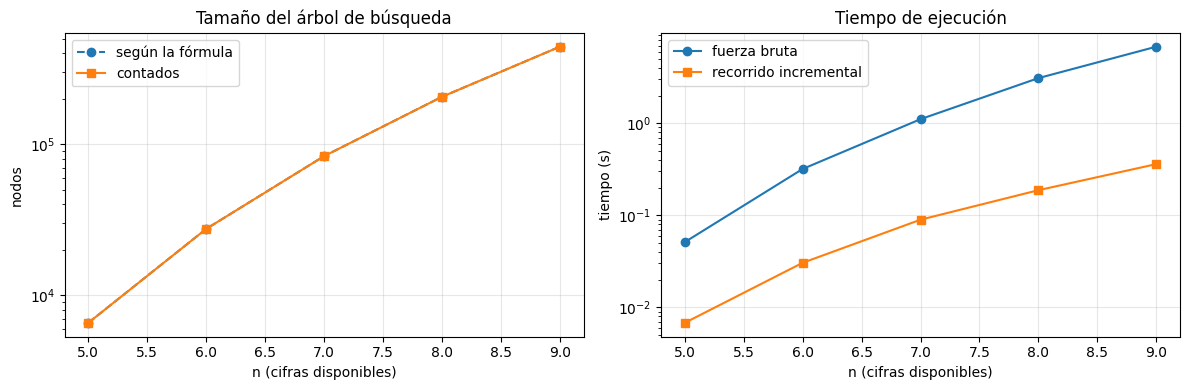

In [10]:
# ============================================================
# COMPROBACIÓN EMPÍRICA DE LA COMPLEJIDAD DEL ALGORITMO MEJORADO
# ============================================================
import matplotlib.pyplot as plt

ns, nodos_contados, nodos_formula, tiempos_fb, tiempos_inc = [], [], [], [], []

for n in range(5, 10):
    subconjunto = tuple(range(1, n + 1))

    # Número de nodos según la fórmula del sumatorio.
    formula = sum((factorial(n) // factorial(n - (i + 1)))
                  * (factorial(4) // factorial(4 - i))
                  for i in range(N_OPS + 1))

    t0 = time.perf_counter()
    _, contados = recorrido_incremental(cifras_disp=subconjunto)
    t_inc = time.perf_counter() - t0

    ns.append(n)
    nodos_contados.append(contados)
    nodos_formula.append(formula)
    tiempos_fb.append(ESCALA[n])          # medido en la pregunta 7
    tiempos_inc.append(t_inc)

print(f"{'n':>3} {'nodos fórmula':>15} {'nodos contados':>16} {'ok':>5} "
      f"{'t f.bruta':>11} {'t incremental':>14} {'mejora':>8}")
for i, n in enumerate(ns):
    print(f"{n:>3} {nodos_formula[i]:>15,} {nodos_contados[i]:>16,} "
          f"{str(nodos_formula[i] == nodos_contados[i]):>5} "
          f"{tiempos_fb[i]:>11.2f} {tiempos_inc[i]:>14.2f} "
          f"{tiempos_fb[i] / tiempos_inc[i]:>7.1f}x")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(ns, nodos_formula, 'o--', label='según la fórmula')
ax[0].plot(ns, nodos_contados, 's-', label='contados')
ax[0].set_yscale('log')
ax[0].set_xlabel('n (cifras disponibles)')
ax[0].set_ylabel('nodos')
ax[0].set_title('Tamaño del árbol de búsqueda')
ax[0].legend()
ax[0].grid(alpha=.3)

ax[1].plot(ns, tiempos_fb, 'o-', label='fuerza bruta')
ax[1].plot(ns, tiempos_inc, 's-', label='recorrido incremental')
ax[1].set_yscale('log')
ax[1].set_xlabel('n (cifras disponibles)')
ax[1].set_ylabel('tiempo (s)')
ax[1].set_title('Tiempo de ejecución')
ax[1].legend()
ax[1].grid(alpha=.3)

plt.tight_layout()
plt.show()

---
## Según el problema (y tenga sentido), diseña un juego de datos de entrada aleatorios

### Respuesta

Cada dato del juego de entrada es un valor objetivo que el algoritmo debe intentar obtener mediante una
expresión válida. El intervalo de valores enteros alcanzables está entre el mínimo $(-69)$ y el máximo
$(77)$, así que lo primero que generamos son valores dentro de ese intervalo. Fijamos una semilla para
que el experimento sea reproducible.

Ese primer conjunto, sin embargo, se queda corto para probar el algoritmo, y al ejecutarlo nos dimos
cuenta. Como todos los enteros de $[-69, 77]$ son alcanzables, cualquier objetivo generado dentro del
intervalo se encuentra siempre, y la rama del programa que avisa de que no hay solución no llega a
ejecutarse nunca. Dicho de otro modo, con ese juego de datos no estamos probando el caso negativo.

Por eso lo hemos ampliado a tres familias, cada una pensada para ejercitar un comportamiento distinto:

1. **Objetivos dentro del rango.** Obligan al algoritmo a encontrar una solución. Es el conjunto de 20
   valores generado con la semilla 1, que incluye positivos, negativos, valores cercanos a cero, el
   propio mínimo $(-69)$ y valores muy próximos al máximo.
2. **Objetivos fuera del rango.** No tienen solución, así que llevan al algoritmo al peor caso y
   permiten comprobar dos cosas: que efectivamente responde que no hay solución, y que la poda se da
   cuenta pronto en lugar de recorrer las 362.880 expresiones.
3. **Objetivos no enteros.** Deben rechazarse sin más, porque el problema solo pregunta por valores
   enteros.

Para estudiar cómo se comporta el algoritmo al cambiar el tamaño del problema generamos además
instancias aleatorias del problema generalizado, con un subconjunto aleatorio de cifras y un
subconjunto aleatorio de operadores. Sirven para ver que los algoritmos siguen siendo correctos fuera
del caso concreto del enunciado.

In [11]:
# ============================================================
# JUEGO DE DATOS DE ENTRADA ALEATORIO
# ============================================================


def generar_objetivos(minimo, maximo, cantidad, semilla=1):
    """
    Genera valores objetivo aleatorios dentro del intervalo [minimo, maximo].
    Se fija la semilla para que el juego de datos sea reproducible.
    """
    aleatorio = random.Random(semilla)
    return [aleatorio.randint(minimo, maximo) for _ in range(cantidad)]


def generar_objetivos_fuera(minimo, maximo, cantidad, semilla=1):
    """Genera objetivos por debajo del mínimo o por encima del máximo."""
    aleatorio = random.Random(semilla)
    valores = []
    for _ in range(cantidad):
        if aleatorio.random() < 0.5:
            valores.append(aleatorio.randint(maximo + 1, maximo + 200))
        else:
            valores.append(aleatorio.randint(minimo - 200, minimo - 1))
    return valores


def generar_objetivos_no_enteros(minimo, maximo, cantidad, semilla=1):
    """Genera objetivos con parte decimal, que no pueden alcanzarse."""
    aleatorio = random.Random(semilla)
    return [aleatorio.randint(minimo, maximo - 1) + 0.5 for _ in range(cantidad)]


def generar_instancias(cantidad, semilla=1):
    """
    Genera instancias aleatorias del problema generalizado: un subconjunto de
    cifras y un subconjunto de operadores.
    """
    aleatorio = random.Random(semilla)
    instancias = []
    for _ in range(cantidad):
        instancias.append({
            'cifras': tuple(sorted(aleatorio.sample(digitos, aleatorio.randint(5, 9)))),
            'ops': tuple(aleatorio.sample(operadores, aleatorio.randint(2, 4))),
        })
    return instancias


MINIMO, MAXIMO = RESOLUTOR.rango()

OBJETIVOS_DENTRO = generar_objetivos(MINIMO, MAXIMO, 20, semilla=1)
OBJETIVOS_FUERA = generar_objetivos_fuera(MINIMO, MAXIMO, 5, semilla=1)
OBJETIVOS_NO_ENTEROS = generar_objetivos_no_enteros(MINIMO, MAXIMO, 3, semilla=1)
INSTANCIAS = generar_instancias(5, semilla=1)

print("Juego de datos generado\n")
print("Objetivos dentro del rango:")
print(" ", OBJETIVOS_DENTRO)
print("\nObjetivos fuera del rango:")
print(" ", OBJETIVOS_FUERA)
print("\nObjetivos no enteros:")
print(" ", OBJETIVOS_NO_ENTEROS)

print("\nInstancias del problema generalizado:")
print(f"  {'#':>2} {'cifras':<28} {'operadores':<20} {'expresiones':>12}")
for i, ins in enumerate(INSTANCIAS, 1):
    n, k = len(ins['cifras']), len(ins['ops'])
    espacio = factorial(n) // factorial(n - k - 1) * factorial(k)
    print(f"  {i:>2} {str(ins['cifras']):<28} {str(ins['ops']):<20} {espacio:>12,}")

Juego de datos generado

Objetivos dentro del rango:
  [-35, 76, -53, -4, -39, 57, 46, 51, 28, -16, -45, 55, -62, 30, 41, -69, 45, -1, -11, -43]

Objetivos fuera del rango:
  [273, 108, 193, 175, -245]

Objetivos no enteros:
  [-34.5, 76.5, -52.5]

Instancias del problema generalizado:
   # cifras                       operadores            expresiones
   1 (1, 2, 4, 5, 6, 8)           ('/', '+', '*', '-')       17,280
   2 (1, 4, 5, 7, 9)              ('-', '*', '+')               720
   3 (1, 2, 5, 6, 7, 8, 9)        ('-', '/', '+', '*')       60,480
   4 (1, 2, 3, 4, 5, 6, 8, 9)     ('+', '/', '-')            10,080
   5 (2, 5, 6, 7, 9)              ('*', '/', '-')               720


---
## Aplica el algoritmo al juego de datos generado

### Respuesta

Aplicamos los algoritmos a las tres familias de objetivos y a las instancias generalizadas, y al final
respondemos a las dos preguntas del enunciado.

In [12]:
# ============================================================
# APLICACIÓN 1 - Objetivos dentro del rango
# ============================================================
print("OBJETIVOS DENTRO DEL RANGO\n")
print(f"{'N':>5} {'nodos f.bruta':>14} {'nodos poda':>12} {'mejora':>9}   expresión")

total_fb = total_poda = 0
for objetivo in OBJETIVOS_DENTRO:
    _, n_fb = fuerza_bruta_objetivo(objetivo)
    expr, n_poda = busqueda_con_poda(objetivo)

    # Comprobamos que la expresión encontrada vale realmente lo que debe.
    assert expr is not None, f"No se ha encontrado expresión para {objetivo}"
    assert abs(eval(expr) - objetivo) < 1e-9, f"Expresión incorrecta para {objetivo}"

    total_fb += n_fb
    total_poda += n_poda
    print(f"{objetivo:>5} {n_fb:>14,} {n_poda:>12,} {n_fb / n_poda:>8.1f}x   {expr}")

print(f"{'TOTAL':>5} {total_fb:>14,} {total_poda:>12,} {total_fb / total_poda:>8.1f}x")
print("\nTodas las expresiones se han vuelto a evaluar con eval() y son correctas.")

OBJETIVOS DENTRO DEL RANGO

    N  nodos f.bruta   nodos poda    mejora   expresión
  -35         40,531       19,453      2.1x   2+3-5*8/1


   76        202,197       18,306     11.0x   6+8*9-2/1
  -53         10,517        1,897      5.5x   1+4/2-7*8
   -4            342          506      0.7x   1+2*4/8-6
  -39         10,373        2,212      4.7x   1+4/2-6*7
   57         43,916       15,195      2.9x   2+7*9-8/1
   46         24,387           47    518.9x   1+6*8-9/3
   51         25,083           42    597.2x   1+6*9-8/2
   28         17,907          151    118.6x   1+5*6-9/3
  -16          6,554        1,167      5.6x   1+3-5*8/2
  -45         10,397        2,052      5.1x   1+4/2-6*8


   55         10,523           34    309.5x   1+7*8-4/2
  -62         84,115       27,461      3.1x   3+7-8*9/1
   30         14,043           32    438.8x   1+4*8-6/2
   41         10,379           80    129.7x   1+6*7-4/2
  -69         10,661          958     11.1x   1+4/2-8*9


   45         42,093       17,384      2.4x   2+5*9-6/3
   -1            314           31     10.1x   1+2-3*8/6
  -11          2,210          147     15.0x   1+2-6*7/3
  -43         40,651       18,249      2.2x   2+3-6*8/1
TOTAL        607,193      125,404      4.8x

Todas las expresiones se han vuelto a evaluar con eval() y son correctas.


In [13]:
# ============================================================
# APLICACIÓN 2 - Objetivos fuera del rango y no enteros
# ============================================================
print("OBJETIVOS FUERA DEL RANGO (no tienen solución)\n")
print(f"{'N':>6} {'nodos poda':>12} {'% del árbol':>13}  resultado")

for objetivo in OBJETIVOS_FUERA:
    expr, n_poda = busqueda_con_poda(objetivo)
    assert expr is None, f"No debería haber solución para {objetivo}"
    print(f"{objetivo:>6} {n_poda:>12,} {100 * n_poda / N_NODOS:>12.2f}%  sin solución")

print("\nLa poda se da cuenta enseguida de que el objetivo es inalcanzable y recorre")
print("una parte mínima del árbol, en lugar de las 362.880 expresiones.")

print("\n\nOBJETIVOS NO ENTEROS (deben rechazarse)\n")
for objetivo in OBJETIVOS_NO_ENTEROS:
    print(f"  N = {objetivo:>7}  ->  alcanzable: {RESOLUTOR.es_alcanzable(objetivo)}")

OBJETIVOS FUERA DEL RANGO (no tienen solución)

     N   nodos poda   % del árbol  resultado
   273            9         0.00%  sin solución
   108        6,519         1.48%  sin solución
   193            9         0.00%  sin solución
   175            9         0.00%  sin solución
  -245            9         0.00%  sin solución

La poda se da cuenta enseguida de que el objetivo es inalcanzable y recorre
una parte mínima del árbol, en lugar de las 362.880 expresiones.


OBJETIVOS NO ENTEROS (deben rechazarse)

  N =   -34.5  ->  alcanzable: False
  N =    76.5  ->  alcanzable: False
  N =   -52.5  ->  alcanzable: False


In [14]:
# ============================================================
# APLICACIÓN 3 - Instancias del problema generalizado
# ============================================================
print("INSTANCIAS DEL PROBLEMA GENERALIZADO\n")
print(f"{'#':>2} {'n':>2} {'k':>2} {'expresiones':>12} {'nodos':>10} {'valores':>8} "
      f"{'mín':>6} {'máx':>6} {'faltan':>7} {'t (s)':>7}")

for i, ins in enumerate(INSTANCIAS, 1):
    cifras_ins, ops_ins = ins['cifras'], ins['ops']
    n, k = len(cifras_ins), len(ops_ins)
    espacio = factorial(n) // factorial(n - k - 1) * factorial(k)

    t0 = time.perf_counter()
    tabla, nodos = recorrido_incremental(cifras_ins, ops_ins)
    t = time.perf_counter() - t0

    if tabla:
        lo, hi = min(tabla), max(tabla)
        faltan_ins = sum(1 for x in range(lo, hi + 1) if x not in tabla)
        print(f"{i:>2} {n:>2} {k:>2} {espacio:>12,} {nodos:>10,} {len(tabla):>8} "
              f"{lo:>6} {hi:>6} {faltan_ins:>7} {t:>7.2f}")
    else:
        print(f"{i:>2} {n:>2} {k:>2} {espacio:>12,} {nodos:>10,} {0:>8} "
              f"{'-':>6} {'-':>6} {'-':>7} {t:>7.2f}")

print("\nEn el problema generalizado sí aparecen huecos. Que no los haya en el caso del")
print("enunciado no es una propiedad general, sino algo propio de esta instancia.")

INSTANCIAS DEL PROBLEMA GENERALIZADO

 #  n  k  expresiones      nodos  valores    mín    máx  faltan   t (s)
 1  6  4       17,280     27,486       84    -45     51      13    0.03
 2  5  3          720      1,145       50    -58     67      76    0.00


 3  7  4       60,480     83,335      138    -68     77       8    0.11
 4  8  3       10,080     12,272       22     -6     15       0    0.02
 5  5  3          720      1,145       22    -60     60      99    0.00

En el problema generalizado sí aparecen huecos. Que no los haya en el caso del
enunciado no es una propiedad general, sino algo propio de esta instancia.


In [15]:
# ============================================================
# APLICACIÓN 4 - Las dos preguntas del enunciado
# ============================================================

# --- ¿Qué valor máximo y mínimo se pueden obtener? --------------------------
# Hay que distinguir entre los extremos sobre los ENTEROS y los extremos
# sobre TODOS los valores, porque no coinciden.

mejor_num, mejor_den, mejor_expr = None, None, None
peor_num, peor_den, peor_expr = None, None, None

for cifras in permutations(digitos, N_CIFRAS):
    for ops in permutations(operadores):
        num, den = evaluar_par(cifras, ops)
        if mejor_num is None or num * mejor_den > mejor_num * den:
            mejor_num, mejor_den, mejor_expr = num, den, construir_expresion(cifras, ops)
        if peor_num is None or num * peor_den < peor_num * den:
            peor_num, peor_den, peor_expr = num, den, construir_expresion(cifras, ops)

max_real = Fraction(mejor_num, mejor_den)
min_real = Fraction(peor_num, peor_den)
min_ent, max_ent = RESOLUTOR.rango()

print("VALOR MÁXIMO Y MÍNIMO\n")
print("  Sobre los valores enteros")
print(f"    máximo = {max_ent:>4}   ->  {RESOLUTOR.expresion_de(max_ent)}")
print(f"    mínimo = {min_ent:>4}   ->  {RESOLUTOR.expresion_de(min_ent)}")
print("\n  Sobre todos los valores, incluidos los que no son enteros")
print(f"    máximo = {str(max_real):>7} = {float(max_real):>9.5f}  ->  {mejor_expr}")
print(f"    mínimo = {str(min_real):>7} = {float(min_real):>9.5f}  ->  {peor_expr}")


# --- ¿Se obtienen todos los enteros entre el mínimo y el máximo? ------------
import math

print("\n\n¿SE OBTIENEN TODOS LOS ENTEROS ENTRE EL MÍNIMO Y EL MÁXIMO?\n")

# Lectura 1: tomando como extremos los enteros -69 y 77.
faltan_ent = RESOLUTOR.enteros_que_faltan()
total_ent = max_ent - min_ent + 1
print(f"  Lectura 1 - extremos enteros, intervalo [{min_ent}, {max_ent}]")
print(f"    posiciones en el intervalo : {total_ent}")
print(f"    valores alcanzables        : {len(RESOLUTOR.soluciones)}")
detalle = faltan_ent if faltan_ent else '(ninguno)'
print(f"    faltan                     : {len(faltan_ent)} {detalle}")
print(f"    respuesta                  : {'SÍ' if not faltan_ent else 'NO'}")

# Lectura 2: tomando como extremos los valores reales -495/7 y 473/6.
lo_real, hi_real = math.ceil(min_real), math.floor(max_real)
faltan_real = RESOLUTOR.enteros_que_faltan(lo_real, hi_real)
print(f"\n  Lectura 2 - extremos reales, enteros del intervalo [{lo_real}, {hi_real}]")
print(f"    posiciones en el intervalo : {hi_real - lo_real + 1}")
print(f"    valores alcanzables        : {len(RESOLUTOR.soluciones)}")
print(f"    faltan                     : {len(faltan_real)} {faltan_real}")
print(f"    respuesta                  : {'SÍ' if not faltan_real else 'NO'}")


# --- Validación final --------------------------------------------------------
assert set(RESOLUTOR.soluciones) == set(RESULTADOS_FB)
for valor, expr in RESOLUTOR.soluciones.items():
    assert abs(eval(expr) - valor) < 1e-9, f"Expresión inválida para {valor}"
print(f"\n\nValidación: las {len(RESOLUTOR.soluciones)} expresiones se han "
      f"vuelto a evaluar")
print("una a una y todas dan el valor que les corresponde.")

VALOR MÁXIMO Y MÍNIMO

  Sobre los valores enteros
    máximo =   77   ->  7+8*9-2/1
    mínimo =  -69   ->  1+4/2-8*9

  Sobre todos los valores, incluidos los que no son enteros
    máximo =   473/6 =  78.83333  ->  7-1/6+8*9
    mínimo =  -495/7 = -70.71429  ->  1+2/7-8*9


¿SE OBTIENEN TODOS LOS ENTEROS ENTRE EL MÍNIMO Y EL MÁXIMO?

  Lectura 1 - extremos enteros, intervalo [-69, 77]
    posiciones en el intervalo : 147
    valores alcanzables        : 147
    faltan                     : 0 (ninguno)
    respuesta                  : SÍ

  Lectura 2 - extremos reales, enteros del intervalo [-70, 78]
    posiciones en el intervalo : 149
    valores alcanzables        : 147
    faltan                     : 2 [-70, 78]
    respuesta                  : NO


Validación: las 147 expresiones se han vuelto a evaluar
una a una y todas dan el valor que les corresponde.


### Conclusión sobre las dos preguntas del enunciado

**Valor máximo y mínimo.** Sobre los valores enteros, el máximo es **77** y el mínimo **−69**. Si en
cambio se pregunta por los extremos de la función sin exigir que sean enteros, el máximo es $473/6
\approx 78{,}83$ y el mínimo $-495/7 \approx -70{,}71$.

Se habrá visto que la fuerza bruta y el recorrido incremental devuelven expresiones distintas para el
mismo valor, `7/1-2+8*9` y `7+8*9-2/1` para el 77. No es ninguna contradicción: cada valor se puede
obtener de muchas formas, y cada algoritmo guarda la primera que encuentra según el orden en que
recorre el espacio.

**Todos los enteros intermedios.** La respuesta depende de qué se entienda por "dicho mínimo y máximo",
y por eso damos las dos:

- Si se toman los **extremos enteros**, el intervalo $[-69, 77]$ contiene 147 enteros y los 147 son
  alcanzables. **Sí se obtienen todos.**
- Si se toman los **extremos reales**, los enteros del intervalo van de $-70$ a $78$, que son 149. De
  ellos faltan exactamente dos, $-70$ y $78$. **En esa lectura no se obtienen todos.**

Nos quedamos con la primera lectura como respuesta principal, porque el enunciado pregunta por "todos
los valores enteros posibles" y lo natural es tomar como referencia los extremos enteros. Pero la
segunda merece mencionarse: al ser el conjunto de valores alcanzables un conjunto finito de racionales,
sus extremos no tienen por qué ser enteros, y los dos enteros que quedan justo por fuera del rango
alcanzable son precisamente los que aparecen y desaparecen según cómo se lea la pregunta.

Expresiones con resultado entero: 90,000 de 362,880 (24.8%)
Valores enteros distintos:        147

Los 5 valores con más soluciones:
     5 :  2880 expresiones
     7 :  2824 expresiones
     9 :  2584 expresiones
     8 :  2376 expresiones
    11 :  2256 expresiones

Los 5 valores con menos soluciones:
   -69 :    16 expresiones
   -68 :    16 expresiones
    72 :    32 expresiones
   -67 :    40 expresiones
   -57 :    48 expresiones


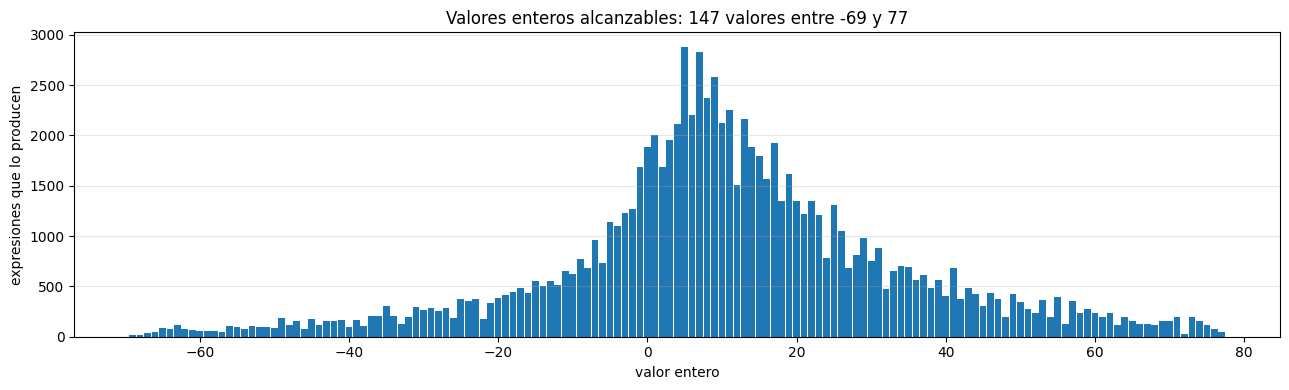

In [16]:
# ============================================================
# APLICACIÓN 5 - Cuántas veces se puede obtener cada valor
# ============================================================
# Esto explica por qué unos objetivos se encuentran mucho antes que otros
# en la búsqueda: no todos los valores tienen la misma cantidad de soluciones.

from collections import Counter

frecuencias = Counter()
for cifras in permutations(digitos, N_CIFRAS):
    for ops in permutations(operadores):
        num, den = evaluar_par(cifras, ops)
        if num % den == 0:
            frecuencias[num // den] += 1

total_enteras = sum(frecuencias.values())
print(f"Expresiones con resultado entero: {total_enteras:,} de {N_EXPRESIONES:,} "
      f"({100 * total_enteras / N_EXPRESIONES:.1f}%)")
print(f"Valores enteros distintos:        {len(frecuencias)}")

print("\nLos 5 valores con más soluciones:")
for valor, veces in frecuencias.most_common(5):
    print(f"  {valor:>4} : {veces:>5} expresiones")

print("\nLos 5 valores con menos soluciones:")
for valor, veces in sorted(frecuencias.items(), key=lambda par: par[1])[:5]:
    print(f"  {valor:>4} : {veces:>5} expresiones")

valores_ordenados = sorted(frecuencias)
plt.figure(figsize=(13, 4))
plt.bar(valores_ordenados, [frecuencias[v] for v in valores_ordenados], width=.9)
plt.xlabel('valor entero')
plt.ylabel('expresiones que lo producen')
plt.title(f'Valores enteros alcanzables: {len(frecuencias)} valores '
          f'entre {min(valores_ordenados)} y {max(valores_ordenados)}')
plt.grid(alpha=.3, axis='y')
plt.tight_layout()
plt.show()

---
## Enumera las referencias que has utilizado (si ha sido necesario) para llevar a cabo el trabajo

### Respuesta

**Material de la asignatura**

1. VIU – 03MIAR *Algoritmos de Optimización*. Sesión 02, VC1: *Introducción a los Algoritmos*. Análisis
   de la complejidad temporal, órdenes de complejidad y componentes de un problema de optimización
   (función objetivo, variables y restricciones).
2. VIU – 03MIAR *Algoritmos de Optimización*. Sesión 03, VC2: *Diseño de Algoritmos*. Vuelta atrás y
   poda, programación dinámica y memoización, y criterios para elegir entre unas técnicas y otras.
3. VIU – 03MIAR *Algoritmos de Optimización*. Sesión 05, VC3: *Algoritmos de búsqueda y problemas tipo*.
4. VIU – 03MIAR *Algoritmos de Optimización*. Sesión 06, VC4: *Trabajo Práctico*. Enunciado del problema.

**Documentación de Python**

5. Python Software Foundation. *itertools — Functions creating iterators for efficient looping*.
   https://docs.python.org/3/library/itertools.html
   Se ha utilizado `permutations` para generar las permutaciones de cifras y de operadores sin
   repetición.
6. Python Software Foundation. *fractions — Rational numbers*.
   https://docs.python.org/3/library/fractions.html
   Se ha utilizado para hacer cálculos exactos y evitar los errores de precisión asociados al `float`,
   sobre todo en las expresiones con división.
7. Python Software Foundation. *random — Generate pseudo-random numbers*.
   https://docs.python.org/3/library/random.html
   Se ha utilizado para generar el juego de datos de entrada, fijando la semilla para que el conjunto
   sea reproducible.
8. Python Software Foundation. *Expressions — Operator precedence*.
   https://docs.python.org/3/reference/expressions.html#operator-precedence
   Consultada para confirmar la precedencia que aplica `eval` y que reproducen nuestras funciones de
   evaluación.

**Bibliografía**

9. Cormen, T. H., Leiserson, C. E., Rivest, R. L. y Stein, C. (2022). *Introduction to Algorithms*
   (4ª ed.). MIT Press. Capítulos 3, sobre notación asintótica, y 15, sobre programación dinámica.
10. Kleinberg, J. y Tardos, É. (2005). *Algorithm Design*. Addison-Wesley. Capítulo 6, sobre la
    equivalencia entre memoización y tabulación.
11. Goldberg, D. (1991). *What Every Computer Scientist Should Know About Floating-Point Arithmetic*.
    ACM Computing Surveys, 23(1), 5–48. Base de la decisión de trabajar con aritmética exacta en lugar
    de coma flotante.

---
## Describe brevemente las lineas de como crees que es posible avanzar en el estudio del problema. Ten en cuenta incluso posibles variaciones del problema y/o variaciones al alza del tamaño

### Respuesta

**Aumentar el tamaño del problema.** Una forma de avanzar sería analizar qué ocurre al aumentar el
número de cifras y de operaciones que se permiten en cada expresión. El espacio crece como
$V_{n,k+1}\cdot k!$, o sea de forma factorial en $k$, así que el número de combinaciones se dispara
enseguida. Con las 9 cifras y los 4 operadores del enunciado el barrido completo tarda menos de un
segundo; con dos operadores más el espacio se multiplica por varios órdenes de magnitud y el método
exacto deja de ser viable. Sería interesante determinar en qué punto exacto, en función de $n$ y de
$k$, la fuerza bruta deja de ser una buena opción.

**Meet in the middle.** La propiedad que ya hemos usado para las cotas, que la expresión es la suma
algebraica de tres términos multiplicativos, permite algo más ambicioso: tabular por separado los
valores que puede tomar cada término y combinarlos después, en lugar de recorrer el producto completo.
En problemas de este tipo esa técnica baja el coste de $O(N)$ a $O(\sqrt{N})$ a cambio de gastar más
memoria. Es la mejora asintótica que nos ha quedado pendiente.

**Cotas más ajustadas.** Las cotas que usamos en la poda, $1/9 \le T \le 72$, son globales y por eso
bastante laxas. Calcularlas en cada nodo a partir de las cifras que quedan disponibles las estrecharía
mucho y haría la poda bastante más eficaz, a cambio de un poco más de cálculo en cada nodo.

**Permitir paréntesis.** En el problema actual se respeta la prioridad habitual de las operaciones pero
no se puede cambiar el orden con paréntesis. Permitirlos multiplicaría el número de posibilidades por
los números de Catalan y obligaría a representar cada expresión como un árbol sintáctico en lugar de
como un par de tuplas. Es la variante que más enriquece el problema y también la que más habría que
rediseñar.

**Permitir repeticiones o añadir operadores.** Dejar que se repitan cifras u operadores, o incorporar
potencias, raíces o el módulo, cambiaría por completo el conjunto de valores alcanzables. Hay que tener
en cuenta que repetir operadores rompe la propiedad de los tres términos, que es la base de nuestras
cotas, así que habría que rehacer la poda desde cero.

**Metaheurísticas.** Cuando el tamaño impida cualquier método exacto habría que pasar a búsqueda local,
recocido simulado o algoritmos genéticos sobre la función objetivo $|valor(E)-N|$, renunciando a la
garantía de encontrar el óptimo. La representación por permutaciones encaja bien con los operadores de
cruce y mutación que se usan en el problema del viajante.

**Sobre el resultado obtenido.** Un apunte final. Que los 147 enteros de $[-69, 77]$ estén todos
cubiertos, sin un solo hueco, no es algo que se pudiera anticipar contando: ha hecho falta enumerar
todas las expresiones. Con 362.880 expresiones para 147 valores la densidad media es holgada, pero eso
no garantizaba que no faltara alguno en los extremos, donde las soluciones escasean: el $-69$ solo se
obtiene de 16 formas distintas. Ahí está la utilidad de disponer de un método exacto, que convierte una
suposición razonable en un hecho comprobado.